In [1]:
# import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from mpmath import hyp1f1

# import relevant constants
from astropy.constants import M_sun, G, c
from scipy.constants import pi
from astropy.constants import M_sun

# figure format
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ['Computer Moden Roman']
})

In [2]:
# ringdown signal

def ringdown(T, M_source, h0=1.0, samples=20000):

    from astropy.constants import M_sun
    from scipy.constants import pi
    from numpy import exp, cos, linspace

    t = linspace(0, T, samples)

    # wave parameters
    M_source = M_source * M_sun.value                   # convert source mass to SI units
    f0 = (1.207 * 10**4) * (M_sun.value / M_source)     # source carrier frequency
    omega0 = 2 * pi * f0
    Gamma = 1.496 * f0                                  # inverse damping time

    # 
    h = h0 * exp(-1 * Gamma * t) * cos(omega0 * t)      # strain signal

    return t, h, omega0

In [3]:
def F_pml(t, y, M_lens):

    from astropy.constants import M_sun, G, c
    from scipy.constants import pi
    from mpmath import hyp1f1
    from numpy import exp, conj, any, where, isnan

    # values
    N = len(t)
    Rs = 2 * (M_lens*M_sun.value) * G.value / c.value**2
    tM = 2 * Rs / c.value

    # frequency
    freqs = np.fft.fftfreq(N, d=t[1]-t[0])

    # angular frequency
    omega = 2 * pi * freqs

    # dimensionless frequency
    nu = (tM / (2 * pi)) * omega

    # amplification factor
    F = np.empty(N, dtype=complex)

    # set zero-component 
    F[0] = 1.0 + 0.0j

    # index range parameter
    k_max = N // 2

    # calculate amplification factor
    for k in range(1, k_max + 1):

        w = nu[k]

        if w <= 0:
            F[k] = 1.0 + 0.0j
            continue

        a = 1.0j * pi * w
        b = 1.0
        z = 1.0j * pi * w * (y**2)

        try:
            hyp = complex(hyp1f1(a,b,z))
        except Exception as exc:
            hyp = 1.0 + 0.0j

        A_num = (2 * pi **2) * w
        A_den = 1 - exp(-2 * (pi**2) * w)

        A = (A_num/A_den)**(1/2)

        F[k] = A * hyp 

    # Nyquist frequency if N is even
    if N % 2 == 0:
        F[k_max] = F[k_max].real + 0.0j
    
    # impose Hermitian symmetry for negative frequencies
    for k in range(1 + k_max + 1):
        F[-k] = conj(F[k]) 

    if any(isnan(F)):
        print("Warning: NaNs present in F; replacing with 1.0 where NaN")
        F = where(isnan(F), 1.0 + 0j, F)

    return F, nu
                              

In [4]:
# signal parameters
#t = np.linspace(0,0.04,20000)
#M_lens = 250 * M_sun.value
#h0 = 1.0                                        # maximum amplitude
#nu0 = 5/4                                       # Fresnel number
#y = 0.1                                         # source position
#M_source = 0.24 * M_lens / nu0                                                 
#f0 = 1.207*10**(4)*(M_sun.value/M_source)
#Gamma = 1.496 * f0
#omega0 = 2*pi*f0
#h = h0 * np.exp(-Gamma*t)*np.cos(omega0 * t)

### Effect of lens mass 


In [5]:
# source
t, h, omega0 = ringdown(T=0.1, M_source=0.24*250/(5/4), samples=10000) 
N = len(t)

# dimensionless Fourier frequencies
freqs = np.fft.fftfreq(N, d=t[1]-t[0])
omega = 2 * pi * freqs
omega_tilde = omega / omega0

# lens plane parameters
M_lens = np.array([100, 200, 300, 400, 500])           # PML masses
y = 0.1                                             # source position

# fourier transform of unlensed signal
h_tilde = np.fft.fft(h)

# amplification factors
F_list = []
nu_list = []

for lens_mass in M_lens:
    F, nu = F_pml(t, y=0.1, M_lens=lens_mass)
    F_list.append(F)
    nu_list.append(nu)

F_arr = np.array(F_list)
nu_arr = np.array(nu_list)

# lensed signals
hL_tilde_list = []
hL_list = []

for F in F_arr:
    hL_tilde_temp = h_tilde * F
    hL_tilde_list.append(hL_tilde_temp)
    
    hL_temp = np.fft.ifft(hL_tilde_temp)
    hL_list.append(hL_temp)

hL_tilde_arr = np.array(hL_tilde_list)
hL_arr = np.array(hL_list)

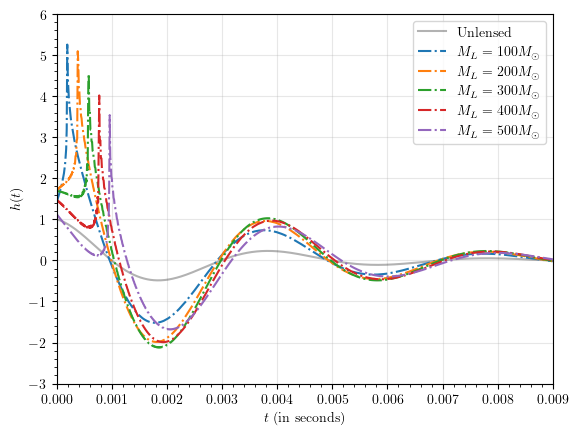

In [6]:
# unlensed vs lensed signals

plt.plot(t, h, alpha=0.3, label="Unlensed", color="black")

plt.plot(t, hL_arr[0].real, label=r"$M_{L} = 100M_{\odot}$", ls="-.")
plt.plot(t, hL_arr[1].real, label=r"$M_{L} = 200M_{\odot}$", ls="-.")
plt.plot(t, hL_arr[2].real, label=r"$M_{L} = 300M_{\odot}$", ls="-.")
plt.plot(t, hL_arr[3].real, label=r"$M_{L} = 400M_{\odot}$", ls="-.")

plt.plot(t, hL_arr[4].real, label=r"$M_{L} = 500M_{\odot}$", ls="-.")

plt.xlim([0,0.009])
plt.ylim([-3,6])

plt.xlabel(r"$t$ (in seconds)")
plt.ylabel(r"$h(t)$")

plt.minorticks_on()

plt.grid(which='major', alpha=0.3)

plt.legend()
plt.show()

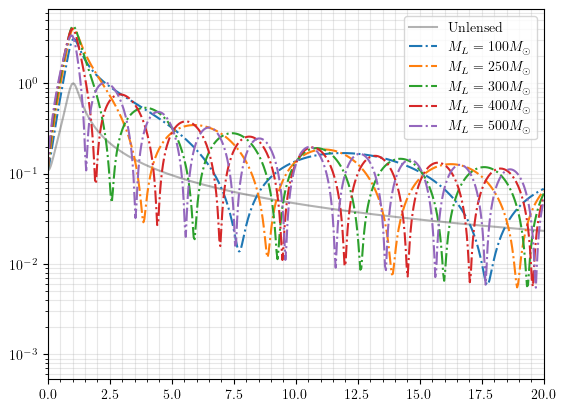

In [7]:
# strain amplitude in frequency domain

plt.plot(omega_tilde[:N//2], np.abs(h_tilde[:N//2])/max(np.abs(h_tilde[:N//2])), color='black', alpha=0.3, label="Unlensed")
plt.plot(omega_tilde[:N//2], np.abs(hL_tilde_arr[0][:N//2])/max(np.abs(h_tilde[:N//2])), label=r'$M_{L} = 100M_{\odot}$', ls='-.')
plt.plot(omega_tilde[:N//2], np.abs(hL_tilde_arr[1][:N//2])/max(np.abs(h_tilde[:N//2])), label=r'$M_{L} = 250M_{\odot}$', ls='-.')
plt.plot(omega_tilde[:N//2], np.abs(hL_tilde_arr[2][:N//2])/max(np.abs(h_tilde[:N//2])), label=r'$M_{L} = 300M_{\odot}$', ls='-.')
plt.plot(omega_tilde[:N//2], np.abs(hL_tilde_arr[3][:N//2])/max(np.abs(h_tilde[:N//2])), label=r'$M_{L} = 400M_{\odot}$', ls='-.')
plt.plot(omega_tilde[:N//2], np.abs(hL_tilde_arr[4][:N//2])/max(np.abs(h_tilde[:N//2])), label=r'$M_{L} = 500M_{\odot}$', ls='-.')

plt.yscale('log')
#plt.xscale('log')
#ax[0].set_xscale('log')

plt.xlim([0,20])

plt.grid(which='both', alpha=0.3)

plt.minorticks_on()

plt.legend()
plt.show()

In [8]:
np.abs(hL_tilde_arr[1][:N//2])/max(np.abs(hL_tilde_arr[1][:N//2]))

array([0.02668287, 0.03245955, 0.03956334, ..., 0.0036545 , 0.00361009,
       0.00356347])